In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.special import erfc
from sklearn.metrics import confusion_matrix
import pandas as pd
import sounddevice as sd
from scipy.io.wavfile import read


\setcounter{secnumdepth}{0}
# OPPGAVE 1

## *A)*

#### Lytte til data

In [3]:
filename = 'm01ae'
filepath = 'Wovels/men/m01ae.wav'
vowdata = 'Wovels/vowdata_nohead.dat'

def play_wav(file_path):
    rate, data = read(file_path)
    sd.play(data, rate)
    sd.wait()

play_wav(filepath)

## *B)*

#### Format loader

In [1]:
import pandas as pd

def load_formant_data(filename, vowdata):
    data = pd.read_csv(vowdata, sep=r'\s+', header=None)
    data.columns = ['Filename', 'Duration', 'F0', 'F1', 'F2', 'F3', 'F4',
                    'F1_2', 'F2_2', 'F3_2', 'F1_3', 'F2_3', 'F3_3',
                    'F1_4', 'F2_4', 'F3_4']
    
    row = data[data['Filename'] == filename]
    if row.empty:
        raise ValueError(f"Filename '{filename}' not found in the data.")
    
    return row[['F1', 'F2', 'F3']].values.flatten()

# Eksempelbruk

formants = load_formant_data(filename, vowdata)
print(formants)

NameError: name 'filename' is not defined

### **Plotting fra alle personene**

#### DATA

In [5]:
def filter_vowdata_by_name(filename, substring):
    filtered_data = []
    with open(filename, 'r') as file:
        for line in file:
            columns = line.strip().split()  # Del opp linjen i kolonner
            if substring in columns[0]:    # Sjekk om substring finnes i kolonne 1
                filtered_data.append(columns)  # Legg til raden i listen
    return filtered_data

# Bruk funksjonen
vowdata = 'Wovels/vowdata_nohead.dat'
filtered_ae_data = filter_vowdata_by_name(vowdata, 'ae')
filtered_ah_data = filter_vowdata_by_name(vowdata, 'ah')
filtered_aw_data = filter_vowdata_by_name(vowdata, 'aw')

F1_ae = []
F1_ah = []
F1_aw = []

F2_ae = []
F2_ah = []
F2_aw = []

F3_ae = []
F3_ah = []
F3_aw = []

for row in filtered_ae_data:
    if float(row[3]) != 0 and float(row[4]) != 0 and float(row[5]) != 0:
        F1_ae.append(float(row[3]))
        F2_ae.append(float(row[4]))
        F3_ae.append(float(row[5]))

for row in filtered_ah_data:
    if float(row[3]) != 0 and float(row[4]) != 0 and float(row[5]) != 0:
        F1_ah.append(float(row[3]))
        F2_ah.append(float(row[4]))
        F3_ah.append(float(row[5]))

for row in filtered_aw_data:
    if float(row[3]) != 0 and float(row[4]) != 0 and float(row[5]) != 0:
        F1_aw.append(float(row[3]))
        F2_aw.append(float(row[4]))
        F3_aw.append(float(row[5]))


# Data fra den markerte koden
classes = ['ae', 'ah', 'aw']
colors = ['blue', 'green', 'red']

# Kombiner data for plotting
F1 = [F1_ae, F1_ah, F1_aw]
F2 = [F2_ae, F2_ah, F2_aw]
F3 = [F3_ae, F3_ah, F3_aw]


#### HISTOGRAM

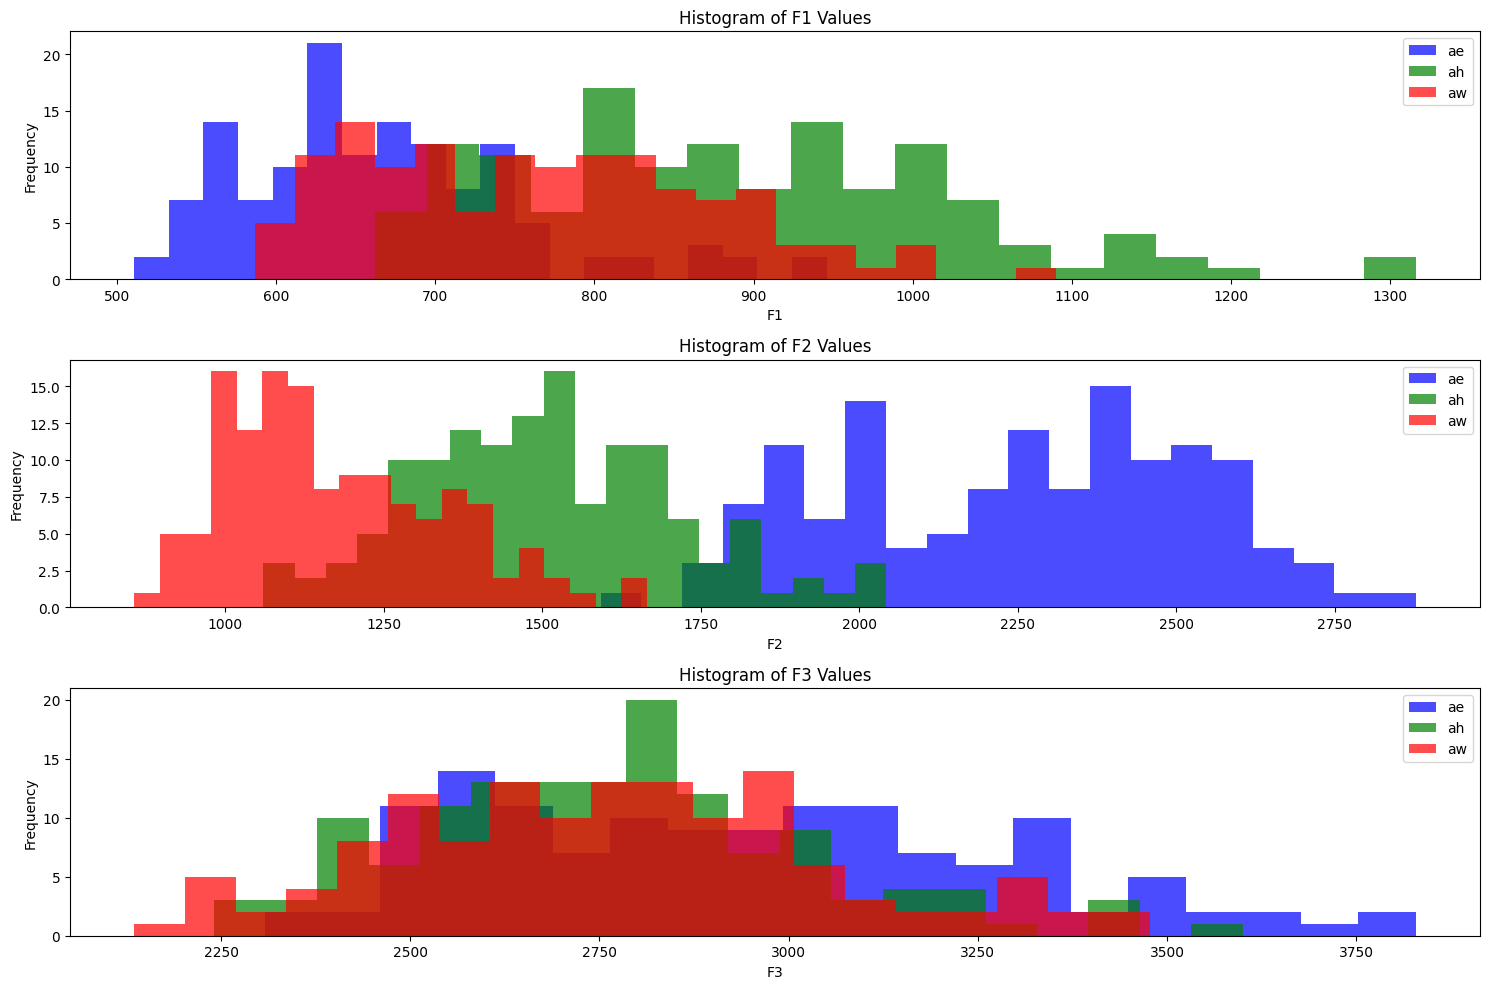

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data fra den markerte koden
classes = ['ae', 'ah', 'aw']
colors = ['blue', 'green', 'red']

# Histogrammer for F1, F2 og F3
plt.figure(figsize=(15, 10))

# F1 histogram
plt.subplot(3, 1, 1)
for i, cls in enumerate(classes):
    plt.hist(F1[i], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of F1 Values')
plt.xlabel('F1')
plt.ylabel('Frequency')
plt.legend()

# F2 histogram
plt.subplot(3, 1, 2)
for i, cls in enumerate(classes):
    plt.hist(F2[i], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of F2 Values')
plt.xlabel('F2')
plt.ylabel('Frequency')
plt.legend()

# F3 histogram
plt.subplot(3, 1, 3)
for i, cls in enumerate(classes):
    plt.hist(F3[i], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of F3 Values')
plt.xlabel('F3')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

#### 2D PLOT

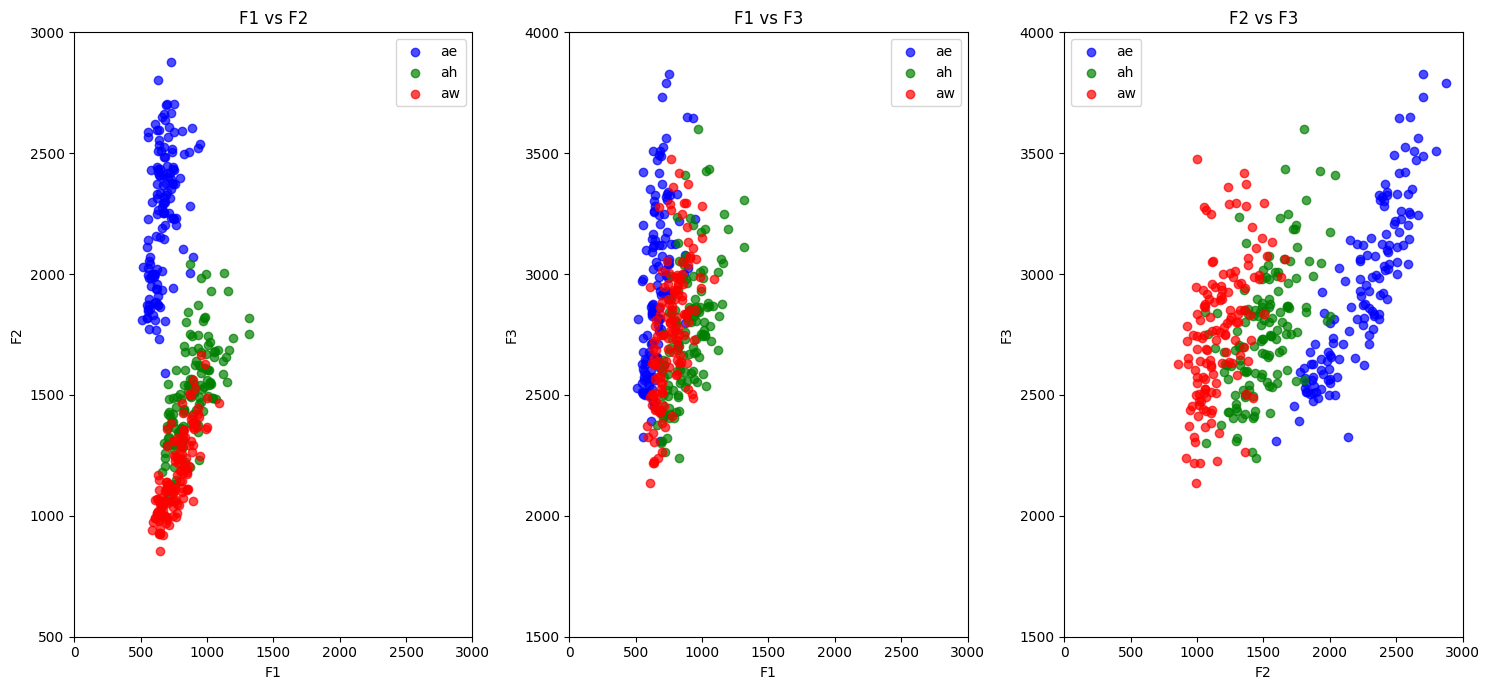

In [7]:
# 2D-plott for F1-F2, F1-F3, F2-F3
plt.figure(figsize=(15, 7))

# F1-F2
plt.subplot(1, 3, 1)
for i, cls in enumerate(classes):
    plt.scatter(F1[i], F2[i], label=cls, color=colors[i], alpha=0.7)
plt.title('F1 vs F2')
plt.xlabel('F1')
plt.ylabel('F2')
plt.xlim(0, 3000)
plt.ylim(500, 3000)
plt.legend()

# F1-F3
plt.subplot(1, 3, 2)
for i, cls in enumerate(classes):
    plt.scatter(F1[i], F3[i], label=cls, color=colors[i], alpha=0.7)
plt.title('F1 vs F3')
plt.xlabel('F1')
plt.ylabel('F3')
plt.xlim(0, 3000)
plt.ylim(1500, 4000)
plt.legend()

# F2-F3
plt.subplot(1, 3, 3)
for i, cls in enumerate(classes):
    plt.scatter(F2[i], F3[i], label=cls, color=colors[i], alpha=0.7)
plt.title('F2 vs F3')
plt.xlabel('F2')
plt.ylabel('F3')
plt.xlim(0, 3000)
plt.ylim(1500, 4000)
plt.legend()

plt.tight_layout()
plt.show()



# OPPGAVE 2

## DATA

In [8]:
vowdata = 'Wovels/vowdata_nohead.dat'
filtered_ae_data = filter_vowdata_by_name(vowdata, 'ae')
filtered_ah_data = filter_vowdata_by_name(vowdata, 'ah')
filtered_aw_data = filter_vowdata_by_name(vowdata, 'aw')

data_ae = []
data_ah = []
data_aw = []

for row in filtered_ae_data:
    data_ae.append([float(row[3]), float(row[4]), float(row[5])])
        
for row in filtered_ah_data:
   
    data_ah.append([float(row[3]), float(row[4]), float(row[5])])

for row in filtered_aw_data:
    data_aw.append([float(row[3]), float(row[4]), float(row[5])])

data_ae = np.array(data_ae)
data_ah = np.array(data_ah)
data_aw = np.array(data_aw)

ae_set1 = data_ae[:70]
ae_set2 = data_ae[70:]

ah_set1 = data_ah[:70]
ah_set2 = data_ah[70:]

aw_set1 = data_aw[:70]
aw_set2 = data_aw[70:]


## A)

In [9]:
def trene_på_sett(set):
    mean_vector = np.mean(set, axis=0)
    covariance_matrix = np.cov(set, rowvar=False)
    return mean_vector, covariance_matrix

mu_ae, cov_ae = trene_på_sett(ae_set1)
mu_ah, cov_ah = trene_på_sett(ah_set1)
mu_aw, cov_aw = trene_på_sett(aw_set1)

print("Mean Vector for ae:", mu_ae)
print("Covariance Matrix for ae:\n", cov_ae)

Mean Vector for ae: [ 620.48571429 2066.55714286 2732.85714286]
Covariance Matrix for ae:
 [[ 3955.44182195  5103.69648033  6796.63561077]
 [ 5103.69648033 53592.91697723 48723.80538302]
 [ 6796.63561077 48723.80538302 60271.7184265 ]]


## B)

mu er $ \mu_{ae} = [\mu_{F1},\mu_{F2},\mu_{F3}]$

Cov matrisen er $\Sigma_{ae} =
\begin{bmatrix}
var(F1) & cov(F1,F2) & cov(F1,F3) \\
cov(F2,F1) & var(F2) & cov(F2,F3) \\
cov(F3,F1) & cov(F3,F2) & var(F3)
\end{bmatrix}$

Lager så flerdimmensjonel normal fordeling gitt $\mu$ og $\Sigma$

#### Funksjonene vi bruker

In [10]:
def gaussian_pdf(x, mu, cov): # Denne finner sannsyneligheten til x gitt av vi har en normalfordeling med mu og cov

    d = len(mu)

    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)

    diff = x - mu

    return np.exp(-0.5 * diff @ inv @ diff) / np.sqrt((2*np.pi)**d * det)



def classify(x): #Denne finner sannsyneligheten for at x tilhører hver av de tre klassene basert på F1, F2 og F3, og returnerer klassen med høyest sannsynelighet

    p_ae = gaussian_pdf(x, mu_ae, cov_ae)
    p_ah = gaussian_pdf(x, mu_ah, cov_ah)
    p_aw = gaussian_pdf(x, mu_aw, cov_aw)

    probs = [p_ae, p_ah, p_aw]

    return np.argmax(probs) #Returnerer klass 0 for ae, 1 for ah og 2 for aw. ikke sannsynelighetstall




### TESTER SÅ PÅ DATA

In [11]:
true_labels = [] #0 er ae, 1 er ah, 2 er aw
pred_labels = [] #Vil fylles med klassene som modellen predikerer 

for x in ae_set2:
    true_labels.append(0)
    pred_labels.append(classify(x))

for x in ah_set2:
    true_labels.append(1)
    pred_labels.append(classify(x))

# aw
for x in aw_set2:
    true_labels.append(2)
    pred_labels.append(classify(x))

cm_test = confusion_matrix(true_labels, pred_labels, labels=[0,1,2])

print(f"confusion matrix for test settet:")
print(cm_test)

print(f"\nError/feil for test settet:")
error_test = 1 - np.trace(cm_test) / np.sum(cm_test)

print(error_test)

confusion matrix for test settet:
[[64  5  0]
 [ 1 66  2]
 [ 0 32 37]]

Error/feil for test settet:
0.19323671497584538


Confusion matrix forteller oss her hvor ofte x forveklses med y $(x→y)$:

$cm =
\begin{bmatrix}
ae→ae & ae→ah & ae→aw \\
ah→ae & ah→ah & ah→aw \\
aw→ae & aw→ah & aw→aw
\end{bmatrix}$

mens error finner prosentvis feil. Matematisk:

$1 - \frac{\text{riktige}}{\text{totalt}}$

## C)

In [12]:
mu_ae, cov_ae = trene_på_sett(ae_set2)
mu_ah, cov_ah = trene_på_sett(ah_set2)
mu_aw, cov_aw = trene_på_sett(aw_set2)

def classify(x): 
    p_ae = gaussian_pdf(x, mu_ae, cov_ae)
    p_ah = gaussian_pdf(x, mu_ah, cov_ah)
    p_aw = gaussian_pdf(x, mu_aw, cov_aw)
    probs = [p_ae, p_ah, p_aw]
    return np.argmax(probs) 

true_labels = [] 
pred_labels = [] 

for x in ae_set1:
    true_labels.append(0)
    pred_labels.append(classify(x))

for x in ah_set1:
    true_labels.append(1)
    pred_labels.append(classify(x))

for x in aw_set1:
    true_labels.append(2)
    pred_labels.append(classify(x))


cm_test = confusion_matrix(true_labels, pred_labels, labels=[0,1,2])

print(f"confusion matrix for test settet:")
print(cm_test)

print(f"\nError/feil for test settet:")
error_test = 1 - np.trace(cm_test) / np.sum(cm_test)

print(error_test)

confusion matrix for test settet:
[[38 29  3]
 [ 0 21 49]
 [ 0  3 67]]

Error/feil for test settet:
0.4


## D)

### *Discuss the difference in performance with respect to training versus test set.*

Klassifikatoren gir bedre resultat på treningssettet enn på testsettet fordi parameterne til de Gaussiske modellene blir estimert fra treningsdataene. Modellen er derfor tilpasset akkurat disse observasjonene, og vil vanligvis gi lavere feilrate på treningssettet enn på data som ikke ble brukt under trening.

### *Further, discuss the variation in test performance for the two cases.*

Testsettet består av nye observasjoner som ikke ble brukt til å estimere middelverdi og kovarians. Siden klassene overlapper i feature-rommet, vil små feil i de estimerte parameterne kunne føre til feilklassifisering. Dette gir derfor en høyere feilrate på testsettet enn på treningssettet.
$\newline$ **Altså; modellen er sensitiv til hvilke samples som brukes til trening**



## E)

Ja, confusion matrixene stemmer med observasjonene fra Problem 1. $\newline$ Histogrammene og 2D-plottene viste at klassene overlapper, spesielt mellom vokalene «ae» og «ah», samt mellom «ah» og «aw». 


Dette ser vi også i confusion matrixene, hvor de fleste feilklassifiseringene skjer mellom disse klassene.

$cm =
\begin{bmatrix}
ae→ae & ae→ah & ae→aw \\
ah→ae & ah→ah & ah→aw \\
aw→ae & aw→ah & aw→aw
\end{bmatrix}, 
B= \begin{bmatrix}
62 & 5 & 0 \\
1 & 66 & 2 \\
0 & 32 & 37
\end{bmatrix}, 
C = \begin{bmatrix}
38 & 29 & 3 \\
1 & 21 & 49 \\
0 & 3 & 67 
\end{bmatrix}$


 Det er derimot færre feil mellom «ae» og «aw», noe som også stemmer med at disse klassene var bedre separert i feature-rommet. Resultatene fra klassifikatoren er derfor i samsvar med den subjektive vurderingen fra Problem 1.